In [20]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_auc_score, RocCurveDisplay)

In [21]:
#import the training and test data
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()


In [22]:
#Initialize logistic regression model
model = LogisticRegression(class_weight= 'balanced', max_iter= 2000)

In [23]:
#train the model
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [24]:
#make predictions
log_predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]

In [25]:
#Accuracy evaluation
accuracy_score(y_test, log_predictions)

0.7352732434350603

In [26]:
#Confusion matrix
print(confusion_matrix(y_test, log_predictions))

[[739 296]
 [ 77 297]]


In [27]:
#Classification report
print(classification_report(y_test, log_predictions))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [28]:
roc_auc_score(y_test, probabilities)

0.8416337285902504

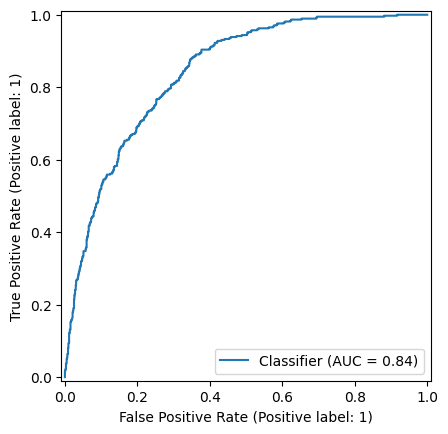

In [29]:
RocCurveDisplay.from_predictions(y_test, probabilities)

In [30]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

In [31]:
#train random forest
rf = RandomForestClassifier(class_weight= 'balanced', random_state= 42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
#train gradient boosting
gb = GradientBoostingClassifier(random_state= 42)
gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [33]:
#predicitons of new models
rf_predictions = rf.predict(X_test)
gb_predictions = gb.predict(X_test)

In [34]:
#table that will compare the three models results
def model_comparison(name: str, y_true, model_predictions):
    return{'Name': name, 
           'Accuracy': accuracy_score(y_true, model_predictions),
           'Precision': precision_score(y_true, model_predictions),
           'Recall': recall_score(y_true, model_predictions),
           'F1 Score': f1_score(y_true, model_predictions)}

results = []
results.append(model_comparison('Logistic Regression', y_test, log_predictions))
results.append(model_comparison('Random Forest', y_test, rf_predictions))
results.append(model_comparison('Gradient Boosting', y_test, gb_predictions))

In [35]:
#put the result in a pandas dataframe
import pandas as pd
results_df  = pd.DataFrame(results)
results_df

,Name,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.735273,0.500843,0.794118,0.614271
1,Random Forest,0.788502,0.632867,0.483957,0.548485
2,Gradient Boosting,0.795600,0.649306,0.500000,0.564955


In [36]:
#Feature importance for Random Forest
important_ft = pd.Series(rf.feature_importances_, index= X_train.columns).sort_values(ascending= False)
important_ft.head(20)

TotalCharges                      0.153941
tenure                            0.149783
MonthlyCharges                    0.146542
Contract_Two year                 0.054148
InternetService_Fiber optic       0.039743
PaymentMethod_Electronic check    0.033227
gender_Male                       0.025637
tenure_groups_0-1 year            0.025393
OnlineSecurity_Yes                0.025239
Contract_One year                 0.025235
PaperlessBilling_Yes              0.025041
TechSupport_Yes                   0.022969
Partner_Yes                       0.021810
tenure_groups_3+ years            0.020321
OnlineBackup_Yes                  0.020243
Dependents_Yes                    0.018957
SeniorCitizen                     0.018914
DeviceProtection_Yes              0.017930
MultipleLines_Yes                 0.017696
StreamingTV_Yes                   0.016123
dtype: float64

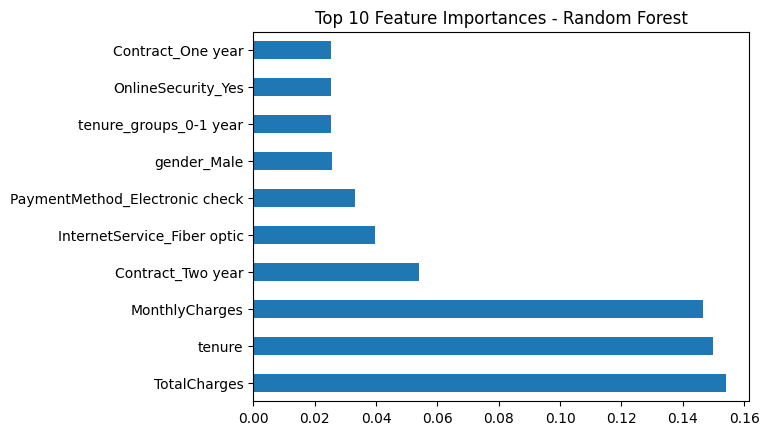

In [37]:
import matplotlib.pyplot as plt

important_ft.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()


In [38]:
weak_features = important_ft.tail(5).index
X_train_reduced = X_train.drop(columns=weak_features)
X_test_reduced = X_test.drop(columns=weak_features)

rf.fit(X_train_reduced, y_train)
rf_new_preds = rf.predict(X_test_reduced)

print("New F1:", f1_score(y_test, rf_new_preds))


New F1: 0.5513016845329249
